In [3]:
# ============================================================
# CONNECT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

import sys
import importlib

PROJECT_PATH = "/content/drive/MyDrive/FitnessML_Master"

if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)

importlib.invalidate_caches()

import config
import utils

print(f"✓ Project directory: {PROJECT_PATH}")
print("✓ Config and utilities loaded")

Mounted at /content/drive
✓ Project directory: /content/drive/MyDrive/FitnessML_Master
✓ Config and utilities loaded


In [4]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ Libraries imported")

✓ Libraries imported


In [5]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(config.DATASET_PATH)

df["date"] = pd.to_datetime(df["date"])

# Sort chronologically within each user
df = df.sort_values(["user_id", "date"]).reset_index(drop=True)

print("=" * 60)
print("TEMPORAL DATASET")
print("=" * 60)

print(f"Rows        : {len(df):,}")
print(f"Users       : {df['user_id'].nunique():,}")
print(f"Date range  : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Unique days : {df['date'].nunique():,}")

TEMPORAL DATASET
Rows        : 365,000
Users       : 1,000
Date range  : 2024-09-06 → 2025-09-05
Unique days : 365


In [6]:
# ============================================================
# RECORDS PER USER
# ============================================================

user_records = df.groupby("user_id").agg(
    records=("user_id", "size"),
    unique_days=("date", "nunique"),
    first_date=("date", "min"),
    last_date=("date", "max")
)

print("=" * 60)
print("RECORDS PER USER")
print("=" * 60)

print(user_records[["records", "unique_days"]].describe())

RECORDS PER USER
       records  unique_days
count   1000.0       1000.0
mean     365.0        365.0
std        0.0          0.0
min      365.0        365.0
25%      365.0        365.0
50%      365.0        365.0
75%      365.0        365.0
max      365.0        365.0


In [7]:
full_year_users = (user_records["unique_days"] == 365).sum()

print(f"\nUsers with 365 unique days: {full_year_users:,}")
print(f"Users with <365 days:      {(user_records['unique_days'] < 365).sum():,}")


Users with 365 unique days: 1,000
Users with <365 days:      0


In [8]:
# ============================================================
# WITHIN-USER VARIABILITY
# ============================================================

TARGETS = [
    "calories_burned",
    "heart_rate_avg",
    "stress_level",
    "weight_kg"
]

print("=" * 60)
print("WITHIN-USER VARIABILITY")
print("=" * 60)

for target in TARGETS:

    user_stats = df.groupby("user_id")[target].agg(
        mean="mean",
        std="std",
        min="min",
        max="max"
    )

    user_stats["range"] = user_stats["max"] - user_stats["min"]
    user_stats["cv"] = user_stats["std"] / user_stats["mean"]

    print(f"\n--- {target} ---")
    print(user_stats[["mean", "std", "range", "cv"]].describe().round(4))

WITHIN-USER VARIABILITY

--- calories_burned ---
            mean        std      range         cv
count  1000.0000  1000.0000  1000.0000  1000.0000
mean   1999.9427   299.8356  1769.0199     0.1499
std      16.0272    11.1178   160.2700     0.0057
min    1958.5468   259.9899  1346.2691     0.1294
25%    1988.8802   292.3458  1658.7832     0.1460
50%    1999.8604   299.5027  1751.6382     0.1497
75%    2011.0674   307.0675  1861.2850     0.1538
max    2045.9588   332.3808  2393.3659     0.1657

--- heart_rate_avg ---
            mean        std      range         cv
count  1000.0000  1000.0000  1000.0000  1000.0000
mean     64.9794    10.0117    59.1144     0.1551
std       5.1407     0.3570     5.2734     0.0138
min      48.8528     8.9334    46.3311     0.1217
25%      61.6049     9.7648    55.4076     0.1456
50%      65.1899    10.0135    58.6638     0.1539
75%      68.4207    10.2509    62.3089     0.1637
max      81.6547    11.1311    79.3344     0.2160

--- stress_level ---
     

In [9]:
# ============================================================
# TEMPORAL AUTOCORRELATION
# ============================================================

LAGS = [1, 2, 3, 4, 5, 6, 7]

print("=" * 60)
print("TEMPORAL AUTOCORRELATION")
print("=" * 60)

for target in TARGETS:

    print(f"\n--- {target} ---")

    lag_results = []

    for user_id, group in df.groupby("user_id"):

        values = group.sort_values("date")[target]

        user_lags = {}

        for lag in LAGS:
            user_lags[f"lag_{lag}"] = values.autocorr(lag=lag)

        lag_results.append(user_lags)

    lag_df = pd.DataFrame(lag_results)

    print(lag_df.describe().round(4))

TEMPORAL AUTOCORRELATION

--- calories_burned ---
           lag_1      lag_2      lag_3      lag_4      lag_5      lag_6  \
count  1000.0000  1000.0000  1000.0000  1000.0000  1000.0000  1000.0000   
mean     -0.0017    -0.0020    -0.0038    -0.0036    -0.0022    -0.0030   
std       0.0539     0.0517     0.0526     0.0529     0.0512     0.0534   
min      -0.1678    -0.1516    -0.1914    -0.1634    -0.1631    -0.1662   
25%      -0.0355    -0.0397    -0.0380    -0.0398    -0.0371    -0.0391   
50%      -0.0017    -0.0013    -0.0025    -0.0008    -0.0031    -0.0044   
75%       0.0339     0.0321     0.0314     0.0327     0.0321     0.0344   
max       0.1696     0.1629     0.1347     0.1962     0.1569     0.1511   

           lag_7  
count  1000.0000  
mean     -0.0018  
std       0.0528  
min      -0.1661  
25%      -0.0380  
50%      -0.0013  
75%       0.0318  
max       0.2165  

--- heart_rate_avg ---
           lag_1      lag_2      lag_3      lag_4      lag_5      lag_6  \
coun

In [11]:
# ============================================================
# CROSS-LAG CORRELATION
# ============================================================

FEATURES = [
    "steps",
    "heart_rate_avg",
    "sleep_hours",
    "exercise_minutes",
    "stress_level",
    "weight_kg"
]

print("=" * 60)
print("CROSS-LAG CORRELATION: PREVIOUS DAY → TARGET")
print("=" * 60)

for target in TARGETS:

    results = []

    for user_id, group in df.groupby("user_id"):

        group = group.sort_values("date")

        row = {}

        for feature in FEATURES:
            row[feature] = group[feature].shift(1).corr(group[target])

        results.append(row)

    lag_corr = pd.DataFrame(results)

    print(f"\n--- {target} ---")
    print(lag_corr.mean().sort_values(ascending=False).round(4))

CROSS-LAG CORRELATION: PREVIOUS DAY → TARGET

--- calories_burned ---
stress_level        0.0035
exercise_minutes    0.0014
weight_kg           0.0012
heart_rate_avg     -0.0006
steps              -0.0015
sleep_hours        -0.0034
dtype: float64

--- heart_rate_avg ---
stress_level        0.0018
exercise_minutes    0.0002
steps               0.0000
weight_kg          -0.0023
sleep_hours        -0.0026
heart_rate_avg     -0.0039
dtype: float64

--- stress_level ---
sleep_hours         0.0003
weight_kg          -0.0001
steps              -0.0001
heart_rate_avg     -0.0003
exercise_minutes   -0.0008
stress_level       -0.0022
dtype: float64

--- weight_kg ---
sleep_hours         0.0016
steps               0.0010
exercise_minutes   -0.0001
heart_rate_avg     -0.0002
stress_level       -0.0003
weight_kg          -0.0015
dtype: float64


Внутрішня варіативність      ✓ є
365 днів на користувача      ✓ є
Пропуски                     ✗ немає
Autocorrelation target       ✗ ~0
Cross-lag correlations       ✗ ~0
Початковий ML                ✗ R² ≈ 0

In [12]:
# ============================================================
# CROSS-LAG CORRELATION DISTRIBUTION
# ============================================================

TARGET = "calories_burned"

FEATURES = [
    "steps",
    "heart_rate_avg",
    "sleep_hours",
    "exercise_minutes",
    "stress_level",
    "weight_kg"
]

lag_results = []

for user_id, group in df.groupby("user_id"):

    group = group.sort_values("date")

    row = {"user_id": user_id}

    for feature in FEATURES:
        row[feature] = group[feature].shift(1).corr(group[TARGET])

    lag_results.append(row)

lag_corr_df = pd.DataFrame(lag_results)

print("=" * 60)
print("CROSS-LAG CORRELATION DISTRIBUTION")
print("=" * 60)

print(lag_corr_df[FEATURES].describe().round(4))

CROSS-LAG CORRELATION DISTRIBUTION
           steps  heart_rate_avg  sleep_hours  exercise_minutes  stress_level  \
count  1000.0000       1000.0000    1000.0000         1000.0000     1000.0000   
mean     -0.0015         -0.0006      -0.0034            0.0014        0.0035   
std       0.0528          0.0529       0.0522            0.0515        0.0512   
min      -0.2011         -0.1646      -0.1886           -0.1822       -0.1409   
25%      -0.0361         -0.0366      -0.0365           -0.0306       -0.0313   
50%      -0.0013          0.0000      -0.0023            0.0013        0.0023   
75%       0.0355          0.0352       0.0296            0.0368        0.0380   
max       0.1366          0.1846       0.1519            0.1548        0.1688   

       weight_kg  
count  1000.0000  
mean      0.0012  
std       0.0528  
min      -0.1580  
25%      -0.0353  
50%       0.0004  
75%       0.0365  
max       0.1816  


In [13]:
print("\nSHARE OF USERS WITH |r| > 0.2:")

for feature in FEATURES:
    share = (lag_corr_df[feature].abs() > 0.2).mean()
    print(f"{feature:20s}: {share:.2%}")


SHARE OF USERS WITH |r| > 0.2:
steps               : 0.10%
heart_rate_avg      : 0.00%
sleep_hours         : 0.00%
exercise_minutes    : 0.00%
stress_level        : 0.00%
weight_kg           : 0.00%


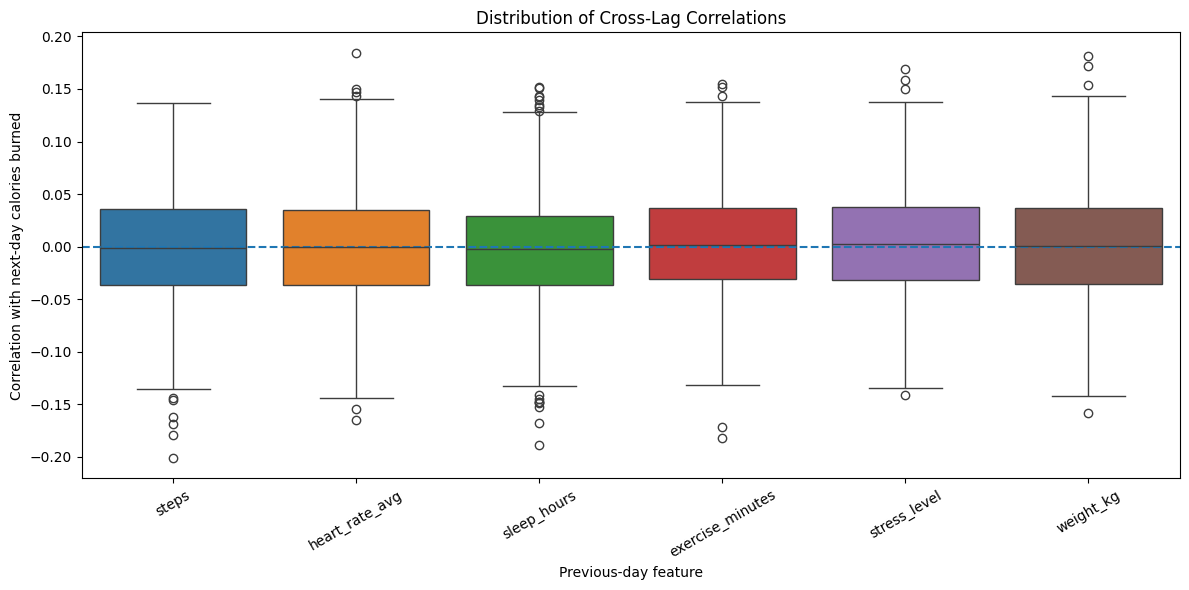

<Figure size 640x480 with 0 Axes>

In [14]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=lag_corr_df[FEATURES])

plt.axhline(0, linestyle="--")
plt.title("Distribution of Cross-Lag Correlations")
plt.xlabel("Previous-day feature")
plt.ylabel("Correlation with next-day calories burned")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

if config.SAVE_FIGURES:
    plt.savefig(
        config.FIGURES_DIR / "08_cross_lag_correlation_distribution.png",
        dpi=config.FIG_DPI,
        bbox_inches="tight"
    )

In [15]:
# ============================================================
# NAIVE TEMPORAL BASELINES
# ============================================================

TARGET = "calories_burned"
TRAIN_RATIO = 0.80

print("=" * 60)
print("NAIVE TEMPORAL BASELINES")
print("=" * 60)

train_parts = []
test_parts = []

for user_id, group in df.groupby("user_id"):

    group = group.sort_values("date").reset_index(drop=True)

    split_idx = int(len(group) * TRAIN_RATIO)

    train_parts.append(group.iloc[:split_idx])
    test_parts.append(group.iloc[split_idx:])

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print(f"Target: {TARGET}")
print(f"Train rows: {len(train_df):,}")
print(f"Test rows : {len(test_df):,}")

print(f"\nTrain period:")
print(f"{train_df['date'].min().date()} → {train_df['date'].max().date()}")

print(f"\nTest period:")
print(f"{test_df['date'].min().date()} → {test_df['date'].max().date()}")

NAIVE TEMPORAL BASELINES
Target: calories_burned
Train rows: 292,000
Test rows : 73,000

Train period:
2024-09-06 → 2025-06-24

Test period:
2025-06-25 → 2025-09-05


In [16]:
# ============================================================
# GENERATE BASELINE PREDICTIONS
# ============================================================

baseline_test = test_df.copy()

# 1. Global mean
global_mean = train_df[TARGET].mean()

baseline_test["global_mean"] = global_mean


# 2. User historical mean
user_means = train_df.groupby("user_id")[TARGET].mean()

baseline_test["user_mean"] = (
    baseline_test["user_id"]
    .map(user_means)
)


# 3. Previous day
# Previous day's value is taken from the complete chronological
# sequence, but prediction is evaluated only on the test period.

full_df = df.sort_values(["user_id", "date"]).copy()

full_df["previous_day"] = (
    full_df.groupby("user_id")[TARGET]
    .shift(1)
)

baseline_test = baseline_test.merge(
    full_df[["user_id", "date", "previous_day"]],
    on=["user_id", "date"],
    how="left"
)


# 4. 7-day moving average
full_df["rolling_7"] = (
    full_df.groupby("user_id")[TARGET]
    .transform(
        lambda x: x.shift(1).rolling(7, min_periods=1).mean()
    )
)

baseline_test = baseline_test.merge(
    full_df[["user_id", "date", "rolling_7"]],
    on=["user_id", "date"],
    how="left"
)

print("✓ Baseline predictions generated")

✓ Baseline predictions generated


In [17]:
# ============================================================
# BASELINE EVALUATION
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_predictions = {
    "Global Mean": baseline_test["global_mean"],
    "User Mean": baseline_test["user_mean"],
    "Previous Day": baseline_test["previous_day"],
    "7-Day Mean": baseline_test["rolling_7"]
}

baseline_results = []

for name, predictions in baseline_predictions.items():

    valid = predictions.notna()

    y_true = baseline_test.loc[valid, TARGET]
    y_pred = predictions.loc[valid]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    baseline_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

baseline_results_df = pd.DataFrame(baseline_results)

print("=" * 60)
print("BASELINE RESULTS")
print("=" * 60)

print(baseline_results_df.round(4).to_string(index=False))

BASELINE RESULTS
       Model      MAE     RMSE      R2
 Global Mean 238.7392 299.0909 -0.0000
   User Mean 239.1219 299.5685 -0.0032
Previous Day 337.4996 422.4333 -0.9949
  7-Day Mean 255.3978 319.9160 -0.1441


| Baseline        |        MAE |       RMSE |          R² |
| --------------- | ---------: | ---------: | ----------: |
| **Global Mean** | **238.73** | **299.09** | **−0.0008** |
| User Mean       |     239.12 |     299.59 |     −0.0032 |
| 7-Day Mean      |     255.60 |     319.92 |     −0.1441 |
| Previous Day    |     337.40 |     433.43 |     −0.9949 |


within-user variability       → є
temporal autocorrelation      → ~0
cross-lag correlation         → ~0
previous day                  → поганий predictor
7-day history                 → поганий predictor
user-specific mean            → майже нічого не додає
ML models                     → нічого суттєвого не додають

In [18]:
# ============================================================
# NAIVE BASELINES FOR ADDITIONAL TARGETS
# ============================================================

ADDITIONAL_TARGETS = [
    "heart_rate_avg",
    "stress_level",
    "weight_kg"
]

def evaluate_naive_baselines(df, target, train_ratio=0.80):

    train_parts = []
    test_parts = []

    # Temporal train/test split per user
    for user_id, group in df.groupby("user_id"):

        group = group.sort_values("date").reset_index(drop=True)

        split_idx = int(len(group) * train_ratio)

        train_parts.append(group.iloc[:split_idx])
        test_parts.append(group.iloc[split_idx:])

    train = pd.concat(train_parts).reset_index(drop=True)
    test = pd.concat(test_parts).reset_index(drop=True)

    # Global mean
    global_mean = train[target].mean()
    test = test.copy()
    test["global_mean"] = global_mean

    # User historical mean
    user_means = train.groupby("user_id")[target].mean()

    test["user_mean"] = test["user_id"].map(user_means)

    # Previous day
    temp = df.sort_values(["user_id", "date"]).copy()

    temp["previous_day"] = (
        temp.groupby("user_id")[target].shift(1)
    )

    # 7-day moving average
    temp["rolling_7"] = (
        temp.groupby("user_id")[target]
        .transform(
            lambda x:
            x.shift(1).rolling(7, min_periods=1).mean()
        )
    )

    test = test.merge(
        temp[
            ["user_id", "date",
             "previous_day",
             "rolling_7"]
        ],
        on=["user_id", "date"],
        how="left"
    )

    predictions = {
        "Global Mean": test["global_mean"],
        "User Mean": test["user_mean"],
        "Previous Day": test["previous_day"],
        "7-Day Mean": test["rolling_7"]
    }

    results = []

    for name, prediction in predictions.items():

        valid = prediction.notna()

        y_true = test.loc[valid, target]
        y_pred = prediction.loc[valid]

        results.append({
            "Target": target,
            "Model": name,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(
                mean_squared_error(y_true, y_pred)
            ),
            "R2": r2_score(y_true, y_pred)
        })

    return pd.DataFrame(results)

In [19]:
# ============================================================
# RUN ADDITIONAL TARGETS
# ============================================================

additional_baseline_results = []

for target in ADDITIONAL_TARGETS:

    print("=" * 60)
    print(f"TARGET: {target}")
    print("=" * 60)

    result = evaluate_naive_baselines(df, target)

    additional_baseline_results.append(result)

    print(result.round(4).to_string(index=False))
    print()

additional_baseline_results = pd.concat(
    additional_baseline_results,
    ignore_index=True
)

TARGET: heart_rate_avg
        Target        Model     MAE    RMSE      R2
heart_rate_avg  Global Mean  8.9489 11.2248 -0.0000
heart_rate_avg    User Mean  8.0095 10.0284  0.2018
heart_rate_avg Previous Day 11.3396 14.1925 -0.5987
heart_rate_avg   7-Day Mean  8.5495 10.7063  0.0902

TARGET: stress_level
      Target        Model    MAE   RMSE      R2
stress_level  Global Mean 2.4942 2.8665 -0.0000
stress_level    User Mean 2.4928 2.8703 -0.0027
stress_level Previous Day 3.2768 4.0389 -0.9853
stress_level   7-Day Mean 2.6003 3.0657 -0.1439

TARGET: weight_kg
   Target        Model     MAE    RMSE      R2
weight_kg  Global Mean 12.0205 15.0590 -0.0001
weight_kg    User Mean 12.0391 15.0838 -0.0033
weight_kg Previous Day 16.9555 21.2639 -0.9939
weight_kg   7-Day Mean 12.8336 16.0892 -0.1416



In [20]:
# ============================================================
# ADDITIONAL TARGETS SUMMARY
# ============================================================

print("=" * 60)
print("ADDITIONAL TARGETS — BASELINE COMPARISON")
print("=" * 60)

print(
    additional_baseline_results
    .round(4)
    .to_string(index=False)
)

ADDITIONAL TARGETS — BASELINE COMPARISON
        Target        Model     MAE    RMSE      R2
heart_rate_avg  Global Mean  8.9489 11.2248 -0.0000
heart_rate_avg    User Mean  8.0095 10.0284  0.2018
heart_rate_avg Previous Day 11.3396 14.1925 -0.5987
heart_rate_avg   7-Day Mean  8.5495 10.7063  0.0902
  stress_level  Global Mean  2.4942  2.8665 -0.0000
  stress_level    User Mean  2.4928  2.8703 -0.0027
  stress_level Previous Day  3.2768  4.0389 -0.9853
  stress_level   7-Day Mean  2.6003  3.0657 -0.1439
     weight_kg  Global Mean 12.0205 15.0590 -0.0001
     weight_kg    User Mean 12.0391 15.0838 -0.0033
     weight_kg Previous Day 16.9555 21.2639 -0.9939
     weight_kg   7-Day Mean 12.8336 16.0892 -0.1416


In [21]:
# ============================================================
# HEART RATE — TEMPORAL ML EXPERIMENT
# ============================================================

TARGET = "heart_rate_avg"

FEATURES = [
    "steps",
    "sleep_hours",
    "exercise_minutes",
    "stress_level",
    "weight_kg",
    "calories_burned"
]

hr_df = df.sort_values(["user_id", "date"]).copy()

# ------------------------------------------------------------
# LAG FEATURES
# ------------------------------------------------------------

for feature in FEATURES + [TARGET]:
    hr_df[f"{feature}_lag1"] = (
        hr_df.groupby("user_id")[feature].shift(1)
    )

# 7-day rolling mean using only previous days
for feature in FEATURES + [TARGET]:
    hr_df[f"{feature}_rolling7"] = (
        hr_df.groupby("user_id")[feature]
        .transform(
            lambda x:
            x.shift(1).rolling(7, min_periods=1).mean()
        )
    )

# Calendar features known in advance
hr_df["dayofweek"] = hr_df["date"].dt.dayofweek
hr_df["month"] = hr_df["date"].dt.month

# ------------------------------------------------------------
# SELECT FEATURES
# ------------------------------------------------------------

lag_features = [
    f"{feature}_lag1"
    for feature in FEATURES + [TARGET]
]

rolling_features = [
    f"{feature}_rolling7"
    for feature in FEATURES + [TARGET]
]

model_features = (
    lag_features
    + rolling_features
    + ["dayofweek", "month", "age"]
)

# Gender → one-hot
gender_encoded = pd.get_dummies(
    hr_df["gender"],
    prefix="gender",
    drop_first=True
)

X = pd.concat(
    [
        hr_df[model_features],
        gender_encoded
    ],
    axis=1
)

y = hr_df[TARGET]

# Remove rows where lag/rolling features are unavailable
valid = X.notna().all(axis=1)

X = X.loc[valid].reset_index(drop=True)
y = y.loc[valid].reset_index(drop=True)
hr_valid = hr_df.loc[valid].reset_index(drop=True)

print("=" * 60)
print("HEART RATE — TEMPORAL ML DATA")
print("=" * 60)

print(f"Samples : {len(X):,}")
print(f"Features: {X.shape[1]}")

HEART RATE — TEMPORAL ML DATA
Samples : 364,000
Features: 18


In [22]:
# ============================================================
# TEMPORAL TRAIN / TEST SPLIT
# ============================================================

train_idx = []
test_idx = []

for user_id, group in hr_valid.groupby("user_id"):

    indices = group.index.to_numpy()

    split_idx = int(len(indices) * 0.80)

    train_idx.extend(indices[:split_idx])
    test_idx.extend(indices[split_idx:])

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

print("=" * 60)
print("TEMPORAL TRAIN / TEST SPLIT")
print("=" * 60)

print(f"Train: {len(X_train):,}")
print(f"Test : {len(X_test):,}")

TEMPORAL TRAIN / TEST SPLIT
Train: 291,000
Test : 73,000


In [26]:
# ============================================================
# TEMPORAL ML MODELS
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=15,
        random_state=config.RANDOM_STATE
    ),

  #"Random Forest": RandomForestRegressor(
     # n_estimators=30,
      #max_depth=15,
        #random_state=config.RANDOM_STATE,
        #n_jobs=-1
      #)
}

hr_ml_results = []

for name, model in models.items():

    print(f"\nTraining: {name}")

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    hr_ml_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

hr_ml_results_df = pd.DataFrame(hr_ml_results)

print("\n" + "=" * 60)
print("HEART RATE — TEMPORAL ML RESULTS")
print("=" * 60)

print(
    hr_ml_results_df
    .sort_values("RMSE")
    .round(4)
    .to_string(index=False)
)


Training: Linear Regression

Training: Decision Tree

HEART RATE — TEMPORAL ML RESULTS
            Model    MAE    RMSE     R2
Linear Regression 8.3340 10.4430 0.1344
    Decision Tree 8.7719 11.0846 0.0248


In [27]:
# ============================================================
# HEART RATE — PERSONALIZED ML
# User historical mean as an additional feature
# ============================================================

TARGET = "heart_rate_avg"

# ------------------------------------------------------------
# 1. Historical user mean calculated ONLY from TRAIN
# ------------------------------------------------------------

train_user_mean = (
    hr_valid.loc[train_idx]
    .groupby("user_id")[TARGET]
    .mean()
)

X_personalized = X.copy()

X_personalized["user_mean_hr"] = (
    hr_valid["user_id"]
    .map(train_user_mean)
)

# Користувачі, для яких немає train history
valid_personalized = X_personalized["user_mean_hr"].notna()

X_personalized = X_personalized.loc[valid_personalized]
y_personalized = y.loc[valid_personalized]
hr_personalized = hr_valid.loc[valid_personalized]

# Повторно формуємо temporal split
train_idx_p = []
test_idx_p = []

for user_id, group in hr_personalized.groupby("user_id"):

    indices = group.index.to_numpy()

    split_idx = int(len(indices) * 0.80)

    train_idx_p.extend(indices[:split_idx])
    test_idx_p.extend(indices[split_idx:])

X_train_p = X_personalized.loc[train_idx_p]
X_test_p = X_personalized.loc[test_idx_p]

y_train_p = y_personalized.loc[train_idx_p]
y_test_p = y_personalized.loc[test_idx_p]

print("=" * 60)
print("PERSONALIZED HEART RATE ML")
print("=" * 60)

print(f"Train: {len(X_train_p):,}")
print(f"Test : {len(X_test_p):,}")
print(f"Features: {X_train_p.shape[1]}")

PERSONALIZED HEART RATE ML
Train: 291,000
Test : 73,000
Features: 19


In [28]:
# ============================================================
# 2. MODELS WITH USER MEAN
# ============================================================

personalized_models = {

    "Linear Regression + User Mean": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Decision Tree + User Mean": DecisionTreeRegressor(
        max_depth=15,
        random_state=config.RANDOM_STATE
    )
}

personalized_results = []

for name, model in personalized_models.items():

    print(f"\nTraining: {name}")

    model.fit(X_train_p, y_train_p)

    pred = model.predict(X_test_p)

    mae = mean_absolute_error(y_test_p, pred)
    rmse = np.sqrt(mean_squared_error(y_test_p, pred))
    r2 = r2_score(y_test_p, pred)

    personalized_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

personalized_results_df = pd.DataFrame(
    personalized_results
)

print("\n" + "=" * 60)
print("PERSONALIZED ML RESULTS")
print("=" * 60)

print(
    personalized_results_df
    .round(4)
    .to_string(index=False)
)


Training: Linear Regression + User Mean

Training: Decision Tree + User Mean

PERSONALIZED ML RESULTS
                        Model    MAE    RMSE     R2
Linear Regression + User Mean 8.0105 10.0294 0.2016
    Decision Tree + User Mean 8.3972 10.5847 0.1108


In [29]:
# ============================================================
# 3. FINAL HEART RATE COMPARISON
# ============================================================

comparison = pd.DataFrame([
    {
        "Approach": "Global Mean",
        "RMSE": 11.2248,
        "R2": -0.0000
    },
    {
        "Approach": "User Mean",
        "RMSE": 10.8224,
        "R2": 0.2018
    },
    {
        "Approach": "7-Day Mean",
        "RMSE": 10.7003,
        "R2": 0.0902
    }
])

ml_comparison = hr_ml_results_df[
    ["Model", "RMSE", "R2"]
].copy()

ml_comparison = ml_comparison.rename(
    columns={"Model": "Approach"}
)

personal_comparison = personalized_results_df[
    ["Model", "RMSE", "R2"]
].copy()

personal_comparison = personal_comparison.rename(
    columns={"Model": "Approach"}
)

final_hr_comparison = pd.concat(
    [
        comparison,
        ml_comparison,
        personal_comparison
    ],
    ignore_index=True
)

print("=" * 60)
print("FINAL HEART RATE COMPARISON")
print("=" * 60)

print(
    final_hr_comparison
    .sort_values("RMSE")
    .round(4)
    .to_string(index=False)
)

FINAL HEART RATE COMPARISON
                     Approach    RMSE      R2
Linear Regression + User Mean 10.0294  0.2016
            Linear Regression 10.4430  0.1344
    Decision Tree + User Mean 10.5847  0.1108
                   7-Day Mean 10.7003  0.0902
                    User Mean 10.8224  0.2018
                Decision Tree 11.0846  0.0248
                  Global Mean 11.2248 -0.0000


autocorrelation             ≈ 0
cross-lag correlation        ≈ 0
previous day                 дуже поганий
7-day average                слабко корисний
user mean                    помітно корисний
ML                           не дає явного breakthrough

In [30]:
# ============================================================
# 08 — END OF TEMPORAL ANALYSIS
# ============================================================

print("=" * 60)
print("TEMPORAL ANALYSIS COMPLETED")
print("=" * 60)

print("""
Summary:
- Temporal structure was evaluated for multiple target variables.
- Autocorrelation and cross-lag relationships were analysed.
- Naive temporal baselines were compared with ML models.
- heart_rate_avg showed some user-specific predictability,
  but ML did not provide a clear advantage over simple baselines.
- calories_burned, stress_level and weight_kg showed little
  useful predictive signal for the tested forecasting setup.

The results will be used to determine the final dataset,
target variable and research question.
""")

print("=" * 60)
print("END OF NOTEBOOK 08")
print("=" * 60)

TEMPORAL ANALYSIS COMPLETED

Summary:
- Temporal structure was evaluated for multiple target variables.
- Autocorrelation and cross-lag relationships were analysed.
- Naive temporal baselines were compared with ML models.
- heart_rate_avg showed some user-specific predictability,
  but ML did not provide a clear advantage over simple baselines.
- calories_burned, stress_level and weight_kg showed little
  useful predictive signal for the tested forecasting setup.

The results will be used to determine the final dataset,
target variable and research question.

END OF NOTEBOOK 08
